In [ ]:
import gc
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy.stats import kruskal

sys.path.append("../scripts")

from utils import make_pseudobulk

# Data preparation for cell-cell communication analysis

This notebook prepares a breast cancer scRNA-seq atlas for downstream analysis.

It includes:
1. Filter donors: remove donors with no tumor cells, fewer than 50 tumor cells, or fewer than 100 non-tumor cells.  
2. Assign PAM50: map PAM50 labels from the previous classification step.  
3. Aggregate cell types: merge cell types into major groups.  
4. Assess TME composition differences: compare major cell type fractions across PAM50 subtypes.  
5. Prepare data for LIANA: keep only genes with HGNC symbols.

## Load data

In [2]:
adata = sc.read_h5ad('../data/7cdea341-ca7a-40fd-8192-b8ecb2d7b91e.h5ad')
adata

AnnData object with n_obs × n_vars = 621200 × 37389
    obs: 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'grade', 'author_cell_type', 'batch', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_rpca', 'X_umap'

## Filter donors by cell count

In [3]:
donors_with_zero_tumor_cell = set(adata.obs['donor_id'].unique()) - set(adata[adata.obs['cell_type'] == 'malignant cell'].obs['donor_id'].unique())

malignant_counts = (
    adata.obs.loc[adata.obs['cell_type'] == 'malignant cell']
    .groupby('donor_id', observed=True)
    .size()
)
donors_with_low_tumor_cell_count = set(malignant_counts[malignant_counts < 50].index.tolist())

not_malignant_counts = (
    adata.obs.loc[adata.obs['cell_type'] != 'malignant cell']
    .groupby('donor_id', observed=True)
    .size()
)
donors_with_low_non_tumor_cell_count = set(not_malignant_counts[not_malignant_counts < 100].index.tolist())

print('Donors without tumor cells:', donors_with_zero_tumor_cell)
print('Donors with less than 50 tumor cells:', donors_with_low_tumor_cell_count)
print('Donors with less than 100 non-tumor cells:', donors_with_low_non_tumor_cell_count)

Donors without tumor cells: {'wu_natgen_CID4040', 'wu_natgen_CID3946'}
Donors with less than 50 tumor cells: {'wu_natgen_CID4398', 'BIOKEY_8', 'wu_natgen_CID3838', 'BC17086-25_Tumor', 'BC428_Tumor', 'BIOKEY_23', 'qian_46', 'qian_50', 'BC258_Tumor', 'qian_52', 'BIOKEY_13'}
Donors with less than 100 non-tumor cells: {'pal_Patient 0056', 'pal_Patient 4031', 'BC401_Tumor', 'pal_Patient 0068'}


Donors who did not pass the threshold will be excluded from further analysis.

In [4]:
bad_donors = donors_with_zero_tumor_cell | donors_with_low_tumor_cell_count | donors_with_low_non_tumor_cell_count
adata_filtered = adata[~adata.obs['donor_id'].isin(bad_donors)].copy()

print('Donors after filtration:', adata_filtered.obs['donor_id'].unique().shape[0])

Donors after filtration: 121


In [5]:
del adata
gc.collect();

## Assign PAM50 subtypes

In [6]:
cluster_labels_result = pd.read_csv('../data/PAM50_cluster_labels_result.tsv', sep='\t', index_col=0).iloc[:, 0]

adata_filtered.obs['PAM50_subtype'] = (
    adata_filtered.obs['donor_id'].map(cluster_labels_result)
)

## Check batch effect in subtype classification

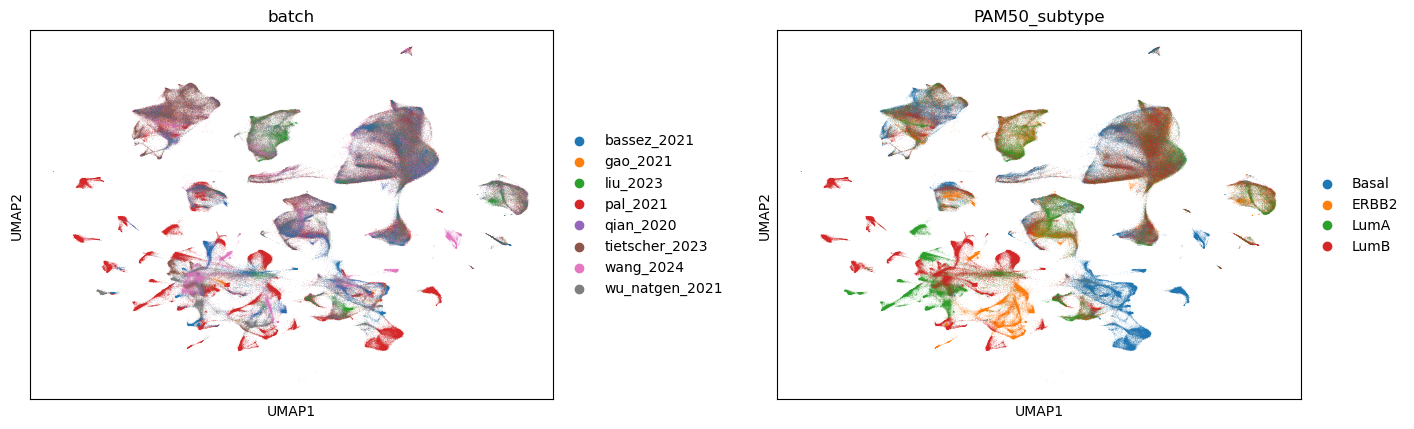

In [7]:
sc.pl.umap(
    adata_filtered,
    color=['batch', 'PAM50_subtype'],
    wspace=0.3
)

There are many small clusters, each colored only `pal_2021`. Each of these clusters also consists of only one subtype. Let's take a closer look at the subtype level:

In [8]:
print(adata_filtered.obs.groupby('PAM50_subtype', observed=True)['donor_id'].nunique().rename('n_donor').to_frame(), '\n')
print(adata_filtered.obs.groupby('PAM50_subtype', observed=True)['batch'].nunique().rename('n_batches').to_frame(), '\n')
print(adata_filtered.obs.groupby('batch', observed=True)['PAM50_subtype'].nunique().rename('n_subpypes').to_frame())

               n_donor
PAM50_subtype         
Basal               31
ERBB2               21
LumA                34
LumB                35 

               n_batches
PAM50_subtype           
Basal                  7
ERBB2                  6
LumA                   7
LumB                   8 

                n_subpypes
batch                     
bassez_2021              4
gao_2021                 2
liu_2023                 3
pal_2021                 4
qian_2020                4
tietscher_2023           3
wang_2024                4
wu_natgen_2021           4


The dataset is very well balanced across donors, batches, and subtypes.

Let's check how batches and donors look within subtypes, and also color cells as tumor/non‑tumor. 

If a cluster is made up almost entirely of tumor cells from a single donor, it likely reflects a donor-specific tumor state. If a cluster mixes multiple donors that all come from the same batch, it likely reflects a batch effect.

I0000 00:00:1779598914.714049  782958 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779598914.716453  782958 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779598916.905373  782958 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779598916.906714  782958 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


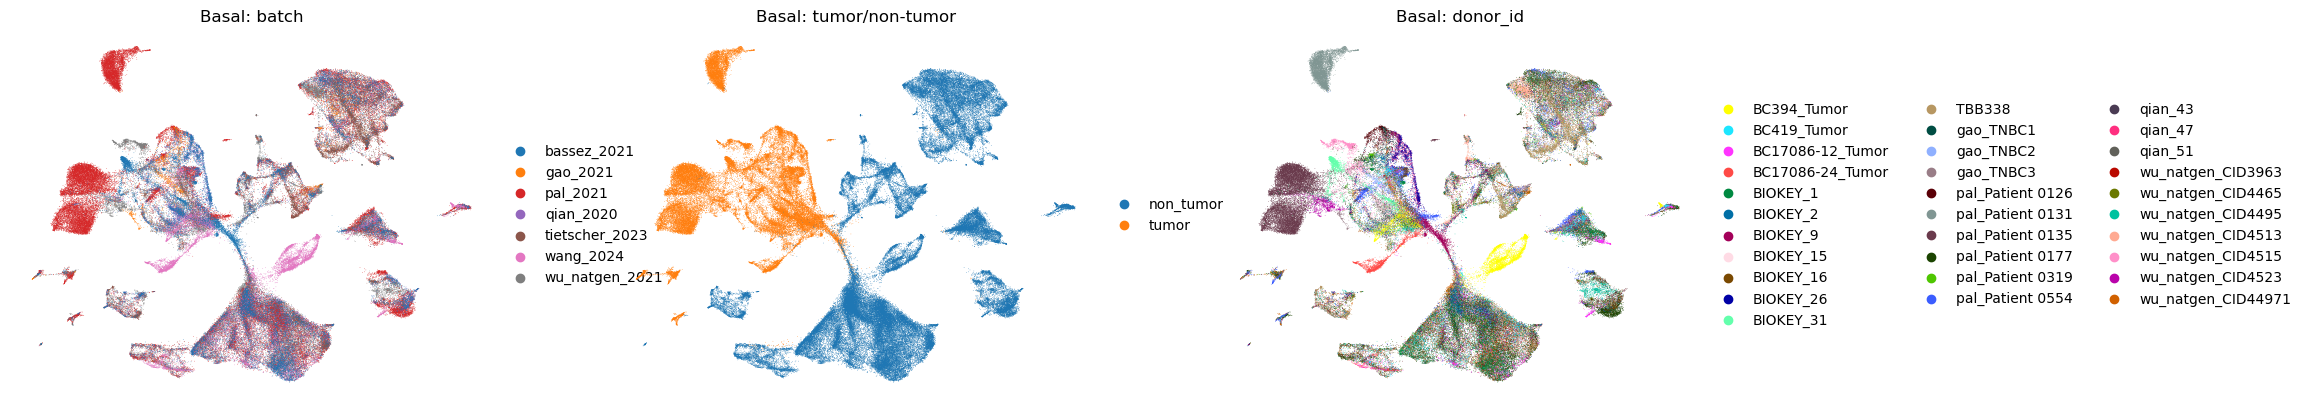

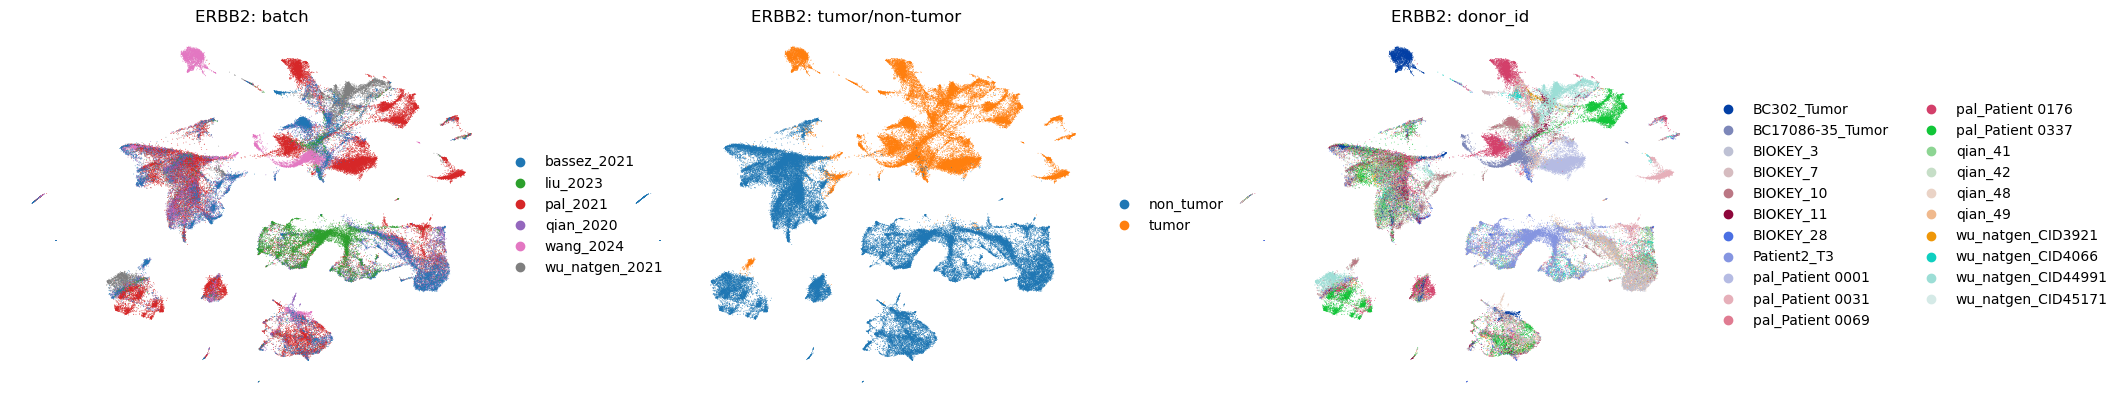

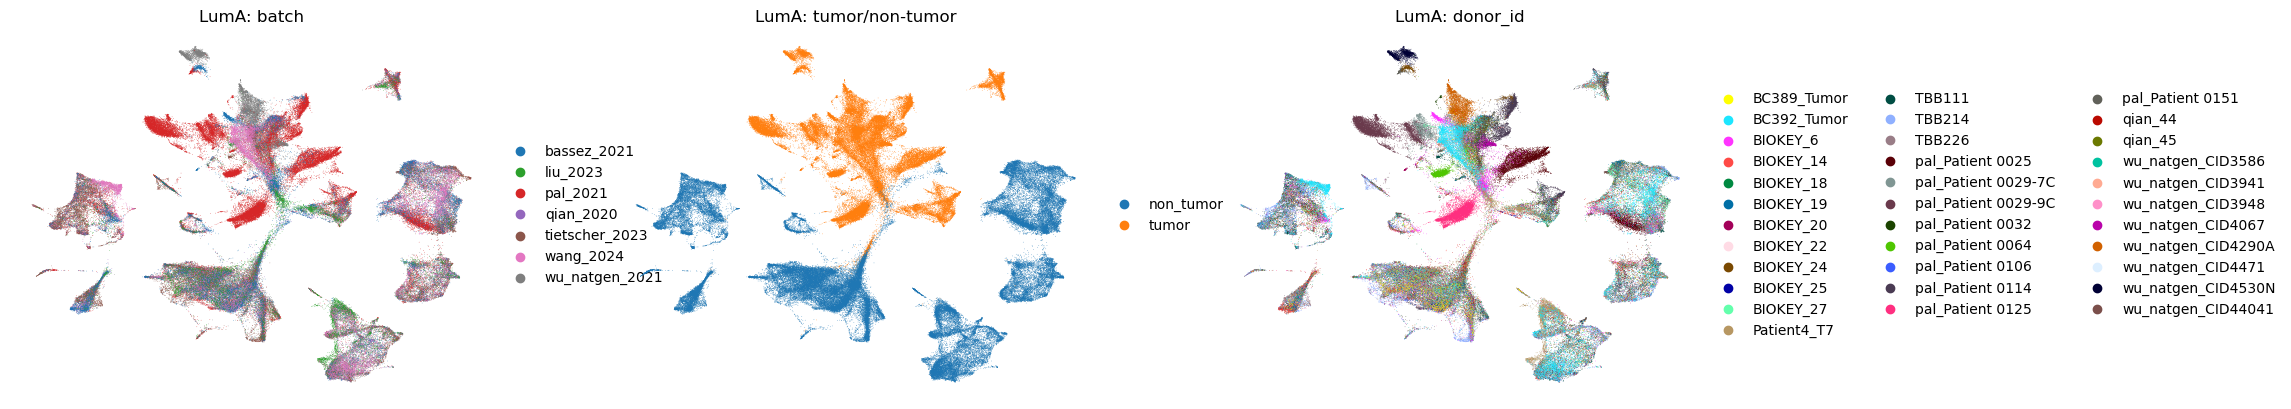

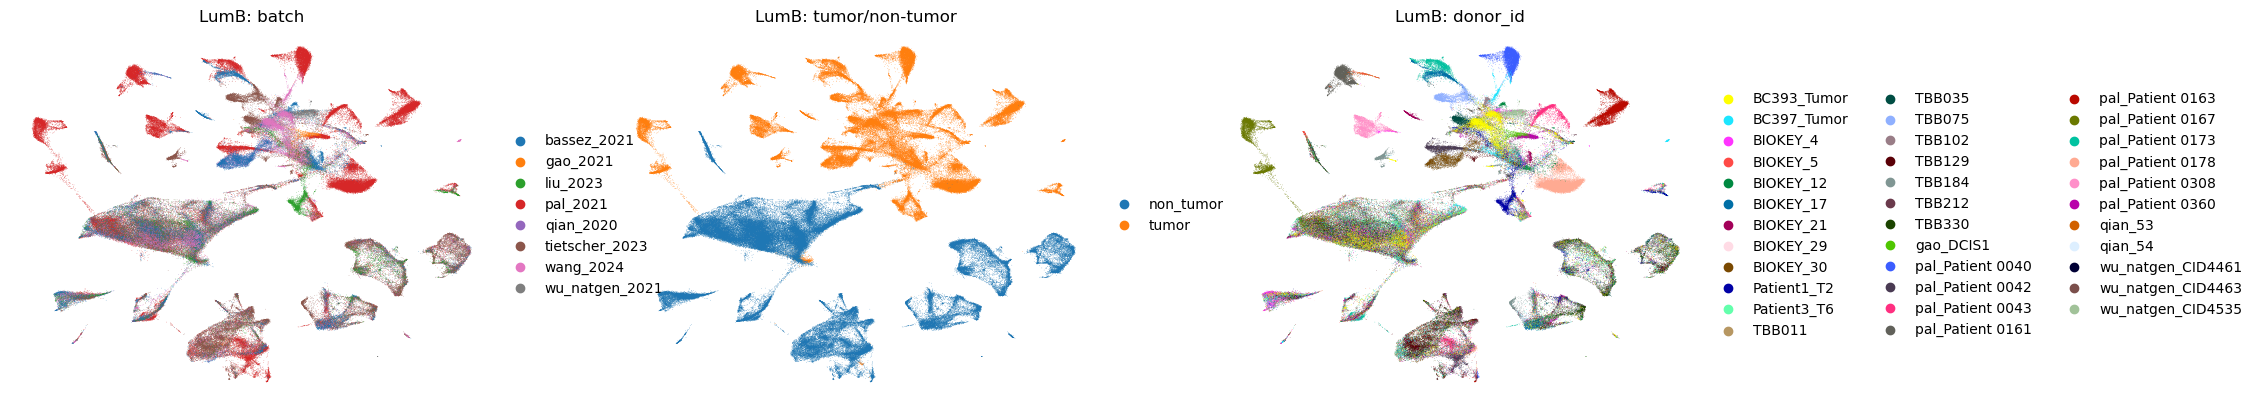

In [9]:
adata_filtered.obs['tumor_status'] = np.where(
    adata_filtered.obs['cell_type'].eq('malignant cell'),
    'tumor',
    'non_tumor',
)

subtype_order = ['Basal', 'ERBB2', 'LumA', 'LumB']

for subtype in subtype_order:
    adata_subtype = adata_filtered[adata_filtered.obs['PAM50_subtype'].eq(subtype)].copy()
    sc.pp.neighbors(adata_subtype, use_rep='X_rpca', n_neighbors=15)
    sc.tl.umap(adata_subtype, min_dist=0.3, random_state=0)

    sc.pl.umap(
        adata_subtype,
        color=('batch', 'tumor_status', 'donor_id'),
        ncols=3,
        frameon=False,
        title=(f'{subtype}: batch', f'{subtype}: tumor/non-tumor', f'{subtype}: donor_id'),
    )

Nearly all single-donor (single-color) clusters consist entirely of tumor cells, consistent with donor-specific malignant states.

## Cell type aggregation

In [10]:
counts = (
    adata_filtered.obs
    .groupby(['cell_type', 'donor_id'], observed=True)
    .size()
    .rename('n_cells')
    .reset_index()
)

counts.groupby('cell_type', observed=True)['n_cells'].describe().sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
cell_type,,,,,,,,
cycling stromal cell,55.0,10.327273,37.050044,1.0,1.00,3.0,6.50,277.0
CD4-positive helper T cell,31.0,13.516129,40.747082,1.0,1.00,2.0,4.50,171.0
myeloid dendritic cell,92.0,13.880435,34.107407,1.0,2.00,4.0,9.00,277.0
capillary endothelial cell,56.0,16.071429,47.519128,1.0,1.00,2.0,6.25,274.0
plasmacytoid dendritic cell,99.0,23.979798,47.252898,1.0,3.00,7.0,22.50,373.0
endothelial cell of artery,106.0,37.773585,70.335019,1.0,3.00,10.0,26.75,370.0
cycling macrophage,115.0,41.278261,109.133071,1.0,4.00,11.0,37.00,923.0
pericyte,110.0,49.663636,77.752994,1.0,6.25,23.5,51.75,445.0
mast cell,83.0,51.156627,103.624614,1.0,5.00,13.0,41.00,642.0


Twenty-nine cell types were identified in the data, many of which are represented by very small numbers of cells. Since this level of granularity is not needed for the analysis, these cell types will be aggregated into 16 broader subtypes. Cycling T cells were excluded because they could not be unambiguously assigned to any of the broader groups.

In [11]:
major_cell_type_map = {
    'fibroblast': 'Fibroblast_Stromal',
    'cycling stromal cell': 'Fibroblast_Stromal',
    'myofibroblast cell': 'Fibroblast_Stromal',

    'macrophage': 'Macrophage',
    'cycling macrophage': 'Macrophage',

    'effector memory CD8-positive, alpha-beta T cell': 'CD8_T',
    'exhausted T cell': 'Exhausted_T',
    'effector memory CD4-positive, alpha-beta T cell': 'CD4_Tconv',
    'naive T cell': 'Naive_T',
    'CD4-positive helper T cell': 'CD4_Tconv',
    'CD4-positive, CD25-positive, CCR4-positive, alpha-beta regulatory T cell': 'Treg',
    'CD8-positive, alpha-beta regulatory T cell': 'Treg',
    'T follicular helper cell': 'Tfh',

    'natural killer cell': 'NK',

    'memory B cell': 'B_memory',
    'IgG plasma cell': 'Plasma',

    'conventional dendritic cell': 'Dendritic_cell',
    'myeloid dendritic cell': 'Dendritic_cell',
    'plasmacytoid dendritic cell': 'Dendritic_cell',

    'endothelial cell': 'Endothelial',
    'vein endothelial cell': 'Endothelial',
    'endothelial cell of vascular tree': 'Endothelial',
    'endothelial cell of artery': 'Endothelial',
    'capillary endothelial cell': 'Endothelial',

    'vascular associated smooth muscle cell': 'Mural',
    'pericyte': 'Mural',
    
    'mast cell': 'Mast',

    'malignant cell': 'Malignant cell',
}

adata_filtered.obs['cell_type_major'] = adata_filtered.obs['cell_type'].astype(str).map(major_cell_type_map)

counts = (
    adata_filtered.obs
    .groupby(['cell_type_major', 'donor_id'], observed=True)
    .size()
    .rename('n_cells')
    .reset_index()
)
counts.groupby('cell_type_major', observed=True)['n_cells'].describe().sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
cell_type_major,,,,,,,,
Mast,83.0,51.156627,103.624614,1.0,5.00,13.0,41.00,642.0
Tfh,108.0,102.842593,140.431921,1.0,7.75,32.0,160.50,635.0
Mural,113.0,125.159292,198.780639,1.0,14.00,50.0,113.00,1245.0
Dendritic_cell,120.0,135.250000,293.507197,1.0,20.75,52.5,105.75,2507.0
Naive_T,114.0,141.728070,232.808527,1.0,18.50,61.0,173.00,1762.0
Exhausted_T,107.0,153.607477,378.458062,1.0,6.00,25.0,188.00,3239.0
Plasma,107.0,163.457944,384.435614,1.0,12.00,50.0,131.50,2415.0
B_memory,108.0,183.111111,300.837626,1.0,14.75,55.5,201.00,2073.0
NK,115.0,192.921739,442.217581,1.0,27.00,87.0,198.00,4432.0


`Mast` cells are still represented by a small number of cells. Most likely they will be excluded from further analysis, as they will not meet the minimum cells-per-donor threshold.

Check if there is bias in the representation of cell types among PAM50 subtypes:

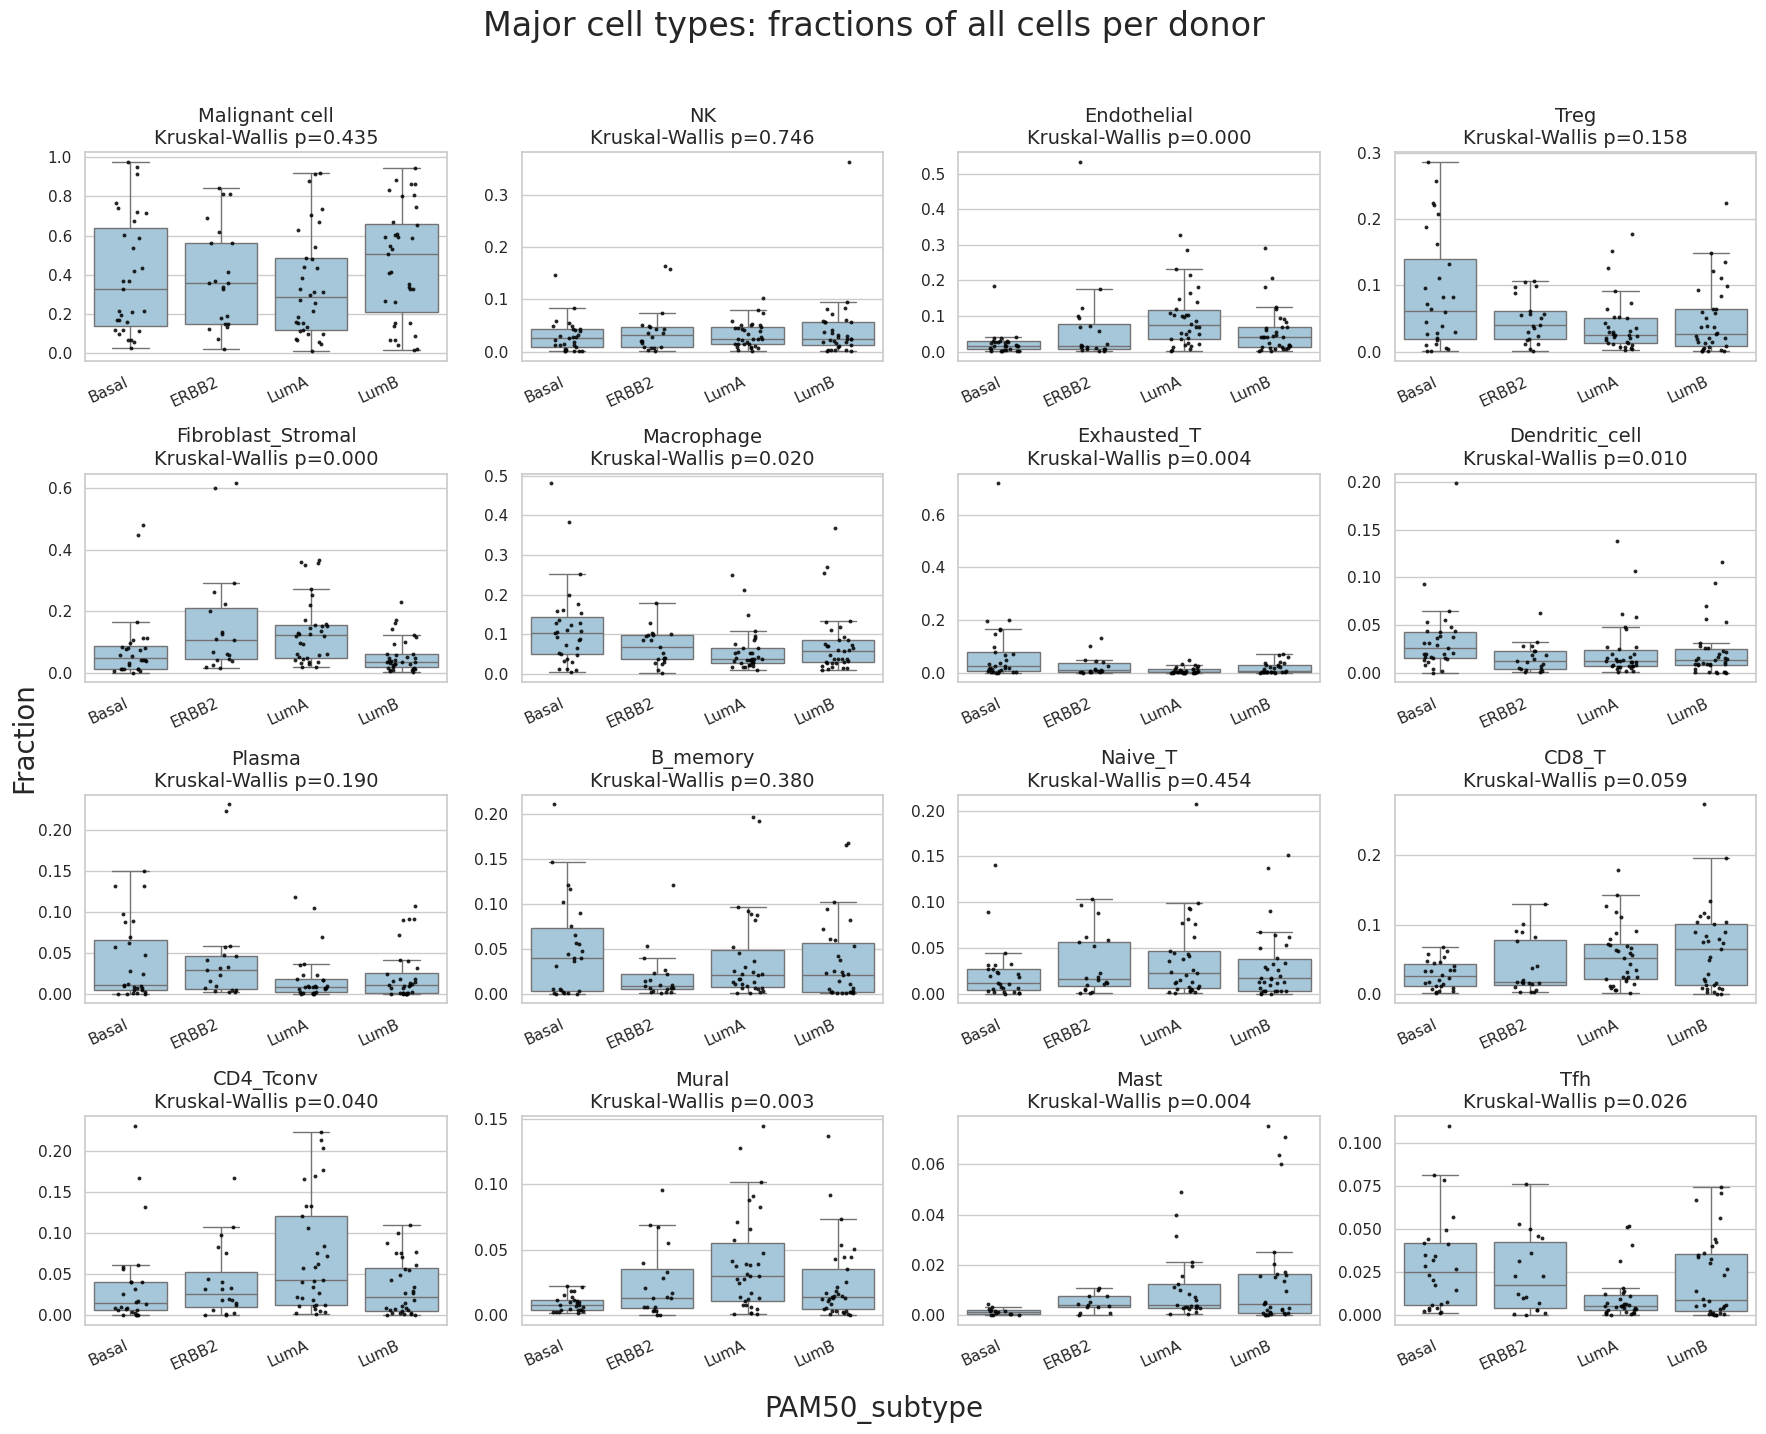

Cell types with p-val < 0.05:


,cell_type_major,pval
0,Endothelial,0.000133
1,Fibroblast_Stromal,0.000160
2,Mural,0.003169
3,Exhausted_T,0.003532
4,Mast,0.003724
5,Dendritic_cell,0.010474
6,Macrophage,0.019671
7,Tfh,0.025678
8,CD4_Tconv,0.039668


In [12]:
sns.set_theme(style='whitegrid')

obs = adata_filtered.obs[['donor_id', 'PAM50_subtype', 'cell_type_major']]

df = (
    obs.value_counts(['donor_id', 'PAM50_subtype', 'cell_type_major'])
       .rename('n')
       .reset_index()
)
df['fraction'] = df['n'] / df.groupby('donor_id', observed=True)['n'].transform('sum')

subtype_order = ['Basal', 'ERBB2', 'LumA', 'LumB']
cell_type_major = df['cell_type_major'].unique().tolist()

ncols = 4
nrows = int(np.ceil(len(cell_type_major) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 14), sharey=False)
axes = np.asarray(axes).ravel()

rows = []

for i, ct in enumerate(cell_type_major):
    ax = axes[i]
    dfi = df[df['cell_type_major'] == ct]

    sns.boxplot(
        data=dfi, x='PAM50_subtype', y='fraction',
        order=subtype_order, color='#9ecae1', showfliers=False,
        linewidth=1.0, ax=ax
    )
    sns.stripplot(
        data=dfi, x='PAM50_subtype', y='fraction',
        order=subtype_order, color='black',
        size=2.8, alpha=0.85, jitter=0.18, ax=ax
    )

    groups = [dfi.loc[dfi['PAM50_subtype'] == st, 'fraction'].to_numpy() for st in subtype_order]
    _, p = kruskal(*groups)
    rows.append({'cell_type_major': ct, 'pval': p})

    ax.set_title(f'{ct}\nKruskal-Wallis p={p:.3f}', fontsize=14)
    ax.set(xlabel='', ylabel='')
    ax.tick_params(axis='x', rotation=25)
    for lab in ax.get_xticklabels():
        lab.set_ha('right')

for ax in axes[i + 1:]:
    ax.axis('off')

fig.suptitle('Major cell types: fractions of all cells per donor', y=1.02, fontsize=24)
fig.supxlabel('PAM50_subtype', fontsize=20)
fig.supylabel('Fraction', fontsize=20)
plt.tight_layout()
plt.show()

res = pd.DataFrame(rows).sort_values('pval').reset_index(drop=True)
sig = res[res['pval'] < 0.05].reset_index(drop=True)

print(f'Cell types with p-val < 0.05:')
display(sig)

For 9 of 15 cell types (excluding `Malignant cells`), relative abundance differs significantly across PAM50 subtypes in the tumor microenvironment, reflecting subtype-specific biology.

## Prepare data for LIANA

By default, LIANA+ uses human gene symbols but the count matrix is indexed by Ensembl gene IDs. 

The HGNC names are kept in `var['feature_name']`, which is a mixture of two nomenclature - it keeps Ensembl gene IDs for genes without HGNC annotation. Also it has several duplicates for HGNC which is assigned to several different Ensembl gene IDs.

In [13]:
print('Total genes:', adata_filtered.n_vars)
print('Ensembl gene IDs:', adata_filtered.var['feature_name'].str.match(r'^ENSG\d{11}$').sum())
print('Duplicated gene names:', adata_filtered.var['feature_name'].duplicated().sum())

Total genes: 37389
Ensembl gene IDs: 11309
Duplicated gene names: 28


The HGNC names are stored in var['feature_name']. This field uses mixed nomenclature: it contains Ensembl gene IDs for genes that lack HGNC annotation. It also includes duplicates where the same HGNC symbol is assigned to multiple Ensembl gene IDs.

Creating a new filtered dataset for LIANA:
- all genes without an HGNC symbol will be removed,
- for duplicated HGNC symbols, the rows with the highest total expression across all cells will be kept,
- `var_names` will contain HGNC symbols

In [14]:
hgnc = adata_filtered.var['feature_name'].astype(str).copy()
mapped_mask = ~hgnc.str.startswith('ENSG').to_numpy()

gene_sums = np.asarray(adata_filtered.raw.X.sum(axis=0)).ravel()

var_mapped = adata_filtered.var.loc[mapped_mask].copy()
var_mapped['hgnc'] = hgnc.to_numpy()[mapped_mask]
var_mapped['gene_sum'] = gene_sums[mapped_mask]
var_mapped['orig_idx'] = np.arange(adata_filtered.n_vars)[mapped_mask]

var_kept = (
    var_mapped.loc[var_mapped.groupby('hgnc')['gene_sum'].idxmax()]
    .sort_values('orig_idx')
    .copy()
)

keep_idx = var_kept['orig_idx'].to_numpy()

new_var = var_kept.drop(columns=['hgnc', 'gene_sum', 'orig_idx']).copy()
new_var.index = var_kept['hgnc'].to_numpy()

adata_filtered_hgnc = ad.AnnData(
    X=adata_filtered.X[:, keep_idx].copy(),
    obs=adata_filtered.obs.copy(),
    var=new_var.copy(),
    obsm={k: v.copy() for k, v in adata_filtered.obsm.items()},
    uns=adata_filtered.uns.copy(),
)
adata_filtered_hgnc.var_names = new_var.index

adata_filtered_hgnc.raw = ad.AnnData(
    X=adata_filtered.raw.X[:, keep_idx].copy(),
    obs=adata_filtered.obs.copy(),
    var=new_var.copy(),
)

Check:

In [15]:
n_genes_initial = adata_filtered.n_vars
n_unmapped_dropped = (~mapped_mask).sum()
n_genes_mapped = mapped_mask.sum()
n_genes_final = adata_filtered_hgnc.n_vars
n_hgnc_duplicates_collapsed = n_genes_mapped - n_genes_final
n_varname_duplicates_final = adata_filtered_hgnc.var_names.duplicated().sum()

print(f'Initial number of genes: {n_genes_initial}')
print(f'Dropped genes without HGNC symbol mapping: {n_unmapped_dropped}')
print(f'Number of genes after dropping unmapped: {n_genes_mapped}')
print(f'Final number of genes after collapsing HGNC duplicates: {n_genes_final}')
print(f'Collapsed HGNC duplicate entries: {n_hgnc_duplicates_collapsed}')

Initial number of genes: 37389
Dropped genes without HGNC symbol mapping: 11309
Number of genes after dropping unmapped: 26080
Final number of genes after collapsing HGNC duplicates: 26052
Collapsed HGNC duplicate entries: 28


## Prepare pseudobulks for edgeR

To enable donor-level expression analysis, single-cell counts were aggregated into pseudobulk profiles by donor and cell type. This produces one count vector per **donor × cell type** combination and makes the data suitable for bulk RNA-seq differential expression tools such as `edgeR`.

These pseudobulks are intended for follow-up testing of whether ligand, receptor, or pathway-related signals highlighted in the communication analysis are also reflected at the expression level within specific cell compartments.

In [17]:
make_pseudobulk(
    adata=adata_filtered,
    donor_col='donor_id',
    group_col='cell_type',
    min_cells=20,
    return_pb=False,
    save=True,
    out_dir='../data/pseudobulks_all_cell_types',
    counts_name='pseudobulks_tumor_counts_gene_by_sample.tsv',
    meta_name='pseudobulks_tumor_sample_metadata.tsv'
)

## Save the filtered datasets

In [18]:
adata_filtered.write_h5ad('../data/data_with_pam50_subtypes_filt_donors_aggr_cell_types.h5ad')
adata_filtered_hgnc.write_h5ad('../data/data_with_pam50_subtypes_filt_donors_aggr_cell_types_hgnc.h5ad')